# Two-Image Face Verification (Same Pipeline as `facial_recognition_lfw_pipeline.ipynb`)

Give this notebook **two facial images** and it answers a single question: **do they show the same person?**

It reuses the *exact* pipeline from the LFW benchmark notebook, with no changes to the model or scoring:

1. **Detect & align** each face with `MTCNN` (`facenet-pytorch`) — same config: `image_size=160`, `margin=14`, `min_face_size=20`, `post_process=True`, `select_largest=True`.
2. **Embed** each aligned `3x160x160` face with `InceptionResnetV1(pretrained='vggface2')` → 512-D vector.
3. **Compare** the two embeddings with **cosine similarity** on L2-normalized vectors.
4. **Decide** MATCH / NON-MATCH by comparing the score to the **EER threshold = 0.3917** that was calibrated on the LFW `test` split in the benchmark notebook.

> Only the decision step is added here. The detector, embedder, and similarity metric are identical to the benchmark, so a pair scored here gets the same number it would inside the LFW loop.

## Step 0 — Install dependencies

Run once. Identical stack to the benchmark notebook — pure PyTorch.

In [33]:
%pip install torch torchvision --quiet
%pip install facenet-pytorch --quiet
%pip install matplotlib numpy pillow --quiet

# NOTE: facenet-pytorch pins an older numpy on some setups. If you hit a
# numpy/torch ABI error, restart the kernel after this cell completes.
print("Dependencies installed.")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencies installed.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1 — Imports & device setup

Same imports and device handling as the benchmark notebook.

In [34]:
import warnings
import numpy as np
import torch
import torchvision
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")  # silence benign MTCNN / PIL warnings
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch        : {torch.__version__}")
print(f"torchvision  : {torchvision.__version__}")
print(f"Using device : {DEVICE}")

torch        : 2.2.2+cpu
torchvision  : 0.17.2+cpu
Using device : cpu


## Step 2 — Choose the two images to compare

Point these at any two image files (JPG/PNG). The defaults use the sample images that ship next to this notebook.

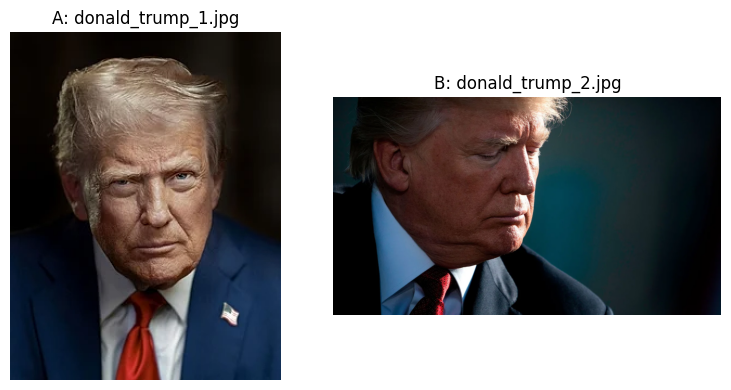

In [35]:
# --- Edit these two paths to compare your own images ---
IMAGE_A = "donald_trump_1.jpg"
IMAGE_B = "donald_trump_2.jpg"

# Decision threshold calibrated on the LFW test split in the benchmark notebook
# (EER threshold). Scores >= this -> MATCH; below -> NON-MATCH.
MATCH_THRESHOLD = 0.3917

# Width of the "uncertain" band around the threshold. Scores within this margin
# are flagged as borderline rather than given a confident yes/no.
UNCERTAIN_MARGIN = 0.05

img_a = Image.open(IMAGE_A).convert("RGB")
img_b = Image.open(IMAGE_B).convert("RGB")

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img_a); ax[0].set_title(f"A: {IMAGE_A}"); ax[0].axis("off")
ax[1].imshow(img_b); ax[1].set_title(f"B: {IMAGE_B}"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## Step 3 — Build the detector (MTCNN) and the embedding backbone

Identical configuration to the benchmark notebook: MTCNN aligns + crops each face to `3x160x160` and prewhitens it; `InceptionResnetV1` with VGGFace2 weights maps it to a 512-D embedding. Inference only (`.eval()`).

In [36]:
mtcnn = MTCNN(
    image_size=160,
    margin=14,
    min_face_size=20,
    post_process=True,   # prewhiten output for the embedding net
    select_largest=True, # if multiple faces, keep the largest
    device=DEVICE,
)

embedder = InceptionResnetV1(pretrained="vggface2").eval().to(DEVICE)

print("MTCNN detector and InceptionResnetV1 (vggface2) embedder are ready.")

MTCNN detector and InceptionResnetV1 (vggface2) embedder are ready.


## Step 4 — Helper functions: align then embed then compare

These are copied verbatim from the benchmark notebook so scoring is bit-for-bit consistent. `score_pair` returns the cosine similarity, or `None` if a face cannot be detected in either image.

In [37]:
@torch.no_grad()
def align_face(pil_img):
    '''Detect + affine-align a single face. Returns a (3,160,160) tensor or None.'''
    try:
        face = mtcnn(pil_img)          # None if no face detected
    except Exception:
        return None
    return face


@torch.no_grad()
def embed_face(face_tensor):
    '''Map an aligned face tensor to a 512-D embedding. Returns a 1-D tensor.'''
    face_tensor = face_tensor.unsqueeze(0).to(DEVICE)  # add batch dim
    emb = embedder(face_tensor)                        # (1, 512)
    return emb.squeeze(0).cpu()


def cosine_similarity(a, b):
    '''Cosine similarity between two 1-D embedding tensors.'''
    a = a / a.norm()
    b = b / b.norm()
    return float(torch.dot(a, b))


def score_pair(pil_a, pil_b):
    '''Full per-pair pipeline. Returns cosine score, or None if either face fails.'''
    fa = align_face(pil_a)
    fb = align_face(pil_b)
    if fa is None or fb is None:
        return None
    return cosine_similarity(embed_face(fa), embed_face(fb))


print("Helper functions defined.")

Helper functions defined.


## Step 5 — Visualize the aligned faces (optional sanity check)

Confirm MTCNN actually found and cropped a face in each image. If a panel is blank, detection failed for that image and the verdict below will say so.

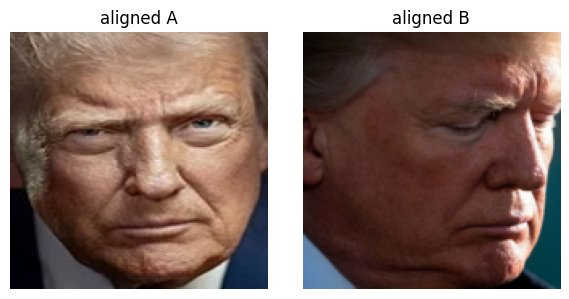

Face A detected: True
Face B detected: True


In [38]:
face_a = align_face(img_a)
face_b = align_face(img_b)


def _to_display(face_tensor):
    '''Undo prewhitening just for display (does not affect scoring).'''
    if face_tensor is None:
        return None
    t = face_tensor.clone()
    t = (t - t.min()) / (t.max() - t.min() + 1e-8)
    return t.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for a, face, name in zip(ax, [face_a, face_b], ["A", "B"]):
    disp = _to_display(face)
    if disp is None:
        a.text(0.5, 0.5, "no face\ndetected", ha="center", va="center", color="crimson")
    else:
        a.imshow(disp)
    a.set_title(f"aligned {name}"); a.axis("off")
plt.tight_layout(); plt.show()

print("Face A detected:", face_a is not None)
print("Face B detected:", face_b is not None)

## Step 6 — Score the pair and return the verdict

Run the full **align → embed → compare** pipeline on the two images and turn the cosine score into a decision using the calibrated threshold. Scores within `UNCERTAIN_MARGIN` of the threshold are flagged as borderline (the "gray area" discussed in the benchmark notebook).

In [39]:
score = score_pair(img_a, img_b)

print("=" * 48)
if score is None:
    verdict = "UNDETERMINED"
    print("Could not detect a face in one or both images.")
    print("Verdict: UNDETERMINED")
else:
    if score >= MATCH_THRESHOLD + UNCERTAIN_MARGIN:
        verdict = "MATCH"
    elif score <= MATCH_THRESHOLD - UNCERTAIN_MARGIN:
        verdict = "NON-MATCH"
    else:
        verdict = "BORDERLINE"

    print(f"Cosine similarity   : {score:.4f}")
    print(f"Decision threshold  : {MATCH_THRESHOLD:.4f}  (+/- {UNCERTAIN_MARGIN} uncertainty band)")
    print(f"Margin from threshold: {score - MATCH_THRESHOLD:+.4f}")
    print("-" * 48)
    if verdict == "MATCH":
        print("Verdict: MATCH  -  same person (confident)")
    elif verdict == "NON-MATCH":
        print("Verdict: NON-MATCH  -  different people (confident)")
    else:
        print("Verdict: BORDERLINE  -  too close to call; "
              "recommend a second image or human review")
print("=" * 48)

Cosine similarity   : 0.6466
Decision threshold  : 0.3917  (+/- 0.05 uncertainty band)
Margin from threshold: +0.2549
------------------------------------------------
Verdict: MATCH  -  same person (confident)


## Step 7 — One-call helper: `verify(path_a, path_b)`

A convenience wrapper so you can verify any two images in a single line, e.g. `verify("a.jpg", "b.jpg")`. Returns a dict with the score and verdict.

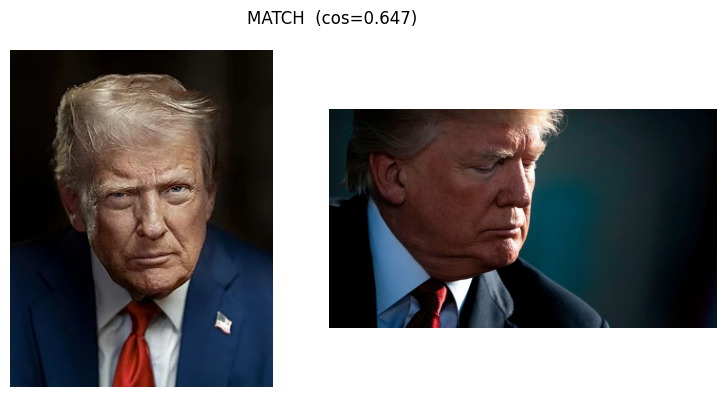

{'score': 0.6465979814529419, 'verdict': 'MATCH', 'same_person': True}

In [40]:
def verify(path_a, path_b, threshold=MATCH_THRESHOLD, margin=UNCERTAIN_MARGIN, show=False):
    '''Verify whether two image files show the same person.

    Returns dict: {'score': float|None, 'verdict': str, 'same_person': bool|None}.
    '''
    a = Image.open(path_a).convert("RGB")
    b = Image.open(path_b).convert("RGB")
    s = score_pair(a, b)

    if s is None:
        result = {"score": None, "verdict": "UNDETERMINED", "same_person": None}
    else:
        if s >= threshold + margin:
            verdict, same = "MATCH", True
        elif s <= threshold - margin:
            verdict, same = "NON-MATCH", False
        else:
            verdict, same = "BORDERLINE", (s >= threshold)
        result = {"score": s, "verdict": verdict, "same_person": same}

    if show:
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(a); ax[0].axis("off")
        ax[1].imshow(b); ax[1].axis("off")
        ttl = result["verdict"] if s is None else f"{result['verdict']}  (cos={s:.3f})"
        fig.suptitle(ttl); plt.tight_layout(); plt.show()
    return result


# Example:
verify(IMAGE_A, IMAGE_B, show=True)

### Notes on interpreting the result

- The threshold `0.3917` is **dataset- and model-specific** — it was calibrated on LFW with this VGGFace2 backbone. Re-calibrate on data representative of your deployment before trusting it in production.
- A score hugging the threshold is the point of **maximum uncertainty**; small changes in lighting, pose, or expression can flip it. That is why borderline scores are surfaced as `BORDERLINE` rather than forced into a yes/no.
- For high-security use, raise the threshold (fewer false accepts); for convenience-first use (e.g. photo tagging), lower it.